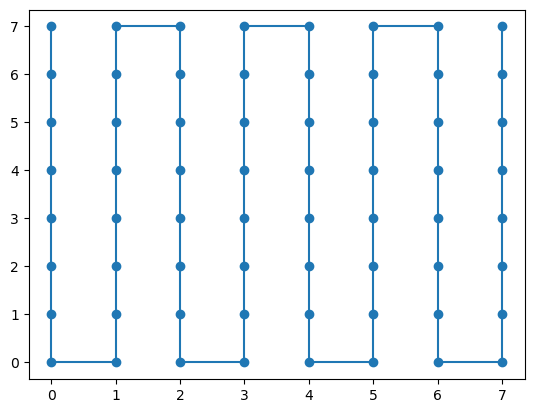

In [12]:
import random


random.seed(0)

def generate_non_intersecting_curve(n):
    # Create all grid points in row-major order
    points = [(x, y) for y in range(n) for x in range(n)]

    # Use a simple backtracking algorithm to generate a Hamiltonian path
    def is_valid(p, path, n):
        return p in points and p not in path

    def neighbors(p, n):
        x, y = p
        return [(x+dx, y+dy) for dx, dy in 
                [(-1,0),(1,0),(0,-1),(0,1)] 
                if 0 <= x+dx < n and 0 <= y+dy < n]

    def dfs(path):
        if len(path) == n * n:
            return path
        current = path[-1]
        next_steps = neighbors(current, n)
        random.shuffle(next_steps)
        for step in next_steps:
            if is_valid(step, path, n):
                path.append(step)
                result = dfs(path)
                if result:
                    return result
                path.pop()
        return None

    start = random.choice(points)
    path = dfs([start])
    return path

def generate_hamiltonian_cycle(n):
    assert n % 2 == 0, "Grid size n must be even for a Hamiltonian cycle."
    path = []
    for y in range(n):
        row = [(x, y) for x in range(n)]
        if y % 2 == 1:
            row.reverse()
        path.extend(row)
    # Connect end back to start to complete the cycle
    return path


def generate_random_hamiltonian_cycle(n):
    assert n % 2 == 0, "Only even-sized grids support Hamiltonian cycles."

    grid = [(x, y) for y in range(n) for x in range(n)]

    def neighbors(p):
        x, y = p
        dirs = [(1,0), (-1,0), (0,1), (0,-1)]
        random.shuffle(dirs)
        for dx, dy in dirs:
            nx, ny = x + dx, y + dy
            if 0 <= nx < n and 0 <= ny < n:
                yield (nx, ny)

    def dfs(path, visited):
        if len(path) == n * n:
            # Check if last connects to start
            if path[0] in list(neighbors(path[-1])):
                return path
            return None

        for nxt in neighbors(path[-1]):
            if nxt not in visited:
                visited.add(nxt)
                path.append(nxt)
                result = dfs(path, visited)
                if result:
                    return result
                path.pop()
                visited.remove(nxt)
        return None

    start = random.choice(grid)
    path = dfs([start], {start})
    return path

def base_cycle(n):
    """Build a simple serpentine Hamiltonian cycle on even-sized grid"""
    path = []
    for y in range(n):
        row = [(x, y) for x in range(n)]
        if y % 2 == 1:
            row.reverse()
        path.extend(row)
    return path

def rotate_point(p, n, angle):
    x, y = p
    if angle == 90:
        return (n - 1 - y, x)
    elif angle == 180:
        return (n - 1 - x, n - 1 - y)
    elif angle == 270:
        return (y, n - 1 - x)
    else:
        return p

def transform_path(path, n):
    """Randomly rotate, flip, or reverse the path"""
    angle = random.choice([0, 90, 180, 270])
    flipped = random.choice([True, False])
    reversed_path = random.choice([True, False])

    new_path = [rotate_point(p, n, angle) for p in path]
    if flipped:
        new_path = [(n - 1 - x, y) for x, y in new_path]
    if reversed_path:
        new_path = list(reversed(new_path))
    return new_path

def generate_random_fast_hamiltonian_cycle(n):
    assert n % 2 == 0, "Only even n supported for Hamiltonian cycles"
    base = base_cycle(n)
    return transform_path(base, n)


# Example usage
#curve = generate_non_intersecting_curve(5)
curve = generate_random_fast_hamiltonian_cycle(8)

x = [p[0] for p in curve]
y = [p[1] for p in curve]
import matplotlib.pyplot as plt
plt.plot(x, y, marker='o')    